# Data Drift Detection in CapyMOA

This tutorial shows how to detect **data drift** (changes in the input data
distribution) using detectors in `capymoa.drift.detectors.data_drift`.

Unlike *concept drift* detectors, which track prediction errors, data drift
detectors compare recent observations against a reference distribution to
determine whether the data-generating process has changed.

In this tutorial we cover:

* A first example with the Kolmogorov–Smirnov test.
* Inspecting the `DataDriftResult` object.
* Comparing statistical test detectors (KS, Anderson–Darling, Cramér–von Mises).
* Comparing distance-based detectors (KL, JS, PSI, Hellinger, Wasserstein, Energy Distance).
* Multivariate detectors (MMD, D3, IBDD, BNDM).
* Categorical features with the Chi-Square test.
* Batch comparison with `compare()`.
* Auto-fit mode for fully streaming workflows.

---

*More information about CapyMOA can be found at* https://www.capymoa.org.

**last update on 03/09/2026**

In [1]:
# This cell is hidden on capymoa.org. See docs/contributing/docs.rst
from util.nbmock import is_nb_fast

# Reduce sizes when running in fast mode (CI / nbmake)
if is_nb_fast():
    _N_REF = 50
    _WINDOW = 20
    _STREAM_LEN = 100
else:
    _N_REF = 500
    _WINDOW = 100
    _STREAM_LEN = 800

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

## Synthetic data with a known drift

We create a simple two-feature stream where the first half is drawn from
`N(0, 1)` and the second half shifts to `N(3, 1)`. This makes it easy to
verify whether detectors fire at the right moment.

In [3]:
N_REF = _N_REF
WINDOW = _WINDOW
STREAM_LEN = _STREAM_LEN
N_FEATURES = 2
SHIFT = 3.0

# Reference data (stable distribution)
X_ref = rng.normal(0, 1, size=(N_REF, N_FEATURES))

# Streaming data: first half is same distribution, second half is shifted
half = STREAM_LEN // 2
X_stream = np.vstack(
    [
        rng.normal(0, 1, size=(half, N_FEATURES)),
        rng.normal(SHIFT, 1, size=(half, N_FEATURES)),
    ]
)

print(f"Reference: {X_ref.shape},  Stream: {X_stream.shape}")
print(f"Drift occurs at observation {half}")

Reference: (500, 2),  Stream: (800, 2)
Drift occurs at observation 400


## 1. A first example with Kolmogorov–Smirnov

The Kolmogorov–Smirnov (KS) test compares the empirical CDFs of the
reference and test windows, feature by feature. It is one of the simplest
and most widely used univariate data-drift detectors.

The workflow is:

1. **Fit** the detector on a reference dataset.
2. **Stream** new observations one at a time with `add_element()`.
3. **Check** for drift with `detected_change()`.

In [4]:
from capymoa.drift.detectors.data_drift import KolmogorovSmirnov

ks = KolmogorovSmirnov(window_size=WINDOW)
ks.fit(X_ref)

detections = []
for i, x in enumerate(X_stream):
    ks.add_element(x)
    if ks.detected_change():
        detections.append(i)

print(f"KS detected drift at observations: {detections}")
print(f"(True drift is at observation {half})")

KS detected drift at observations: [408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538, 539, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576, 577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600,

## 2. Inspecting a `DataDriftResult`

Instead of a simple boolean, you can call `compare()` on any test window
to get a full `DataDriftResult`. This object contains:

- `is_drift` – overall drift decision.
- `statistic` – aggregated test statistic.
- `p_value` – aggregated p-value (for statistical tests).
- `feature_is_drift` – per-feature drift decisions.
- `feature_statistics` – per-feature test statistics.
- `feature_p_values` – per-feature p-values.

In [5]:
ks_fresh = KolmogorovSmirnov(window_size=WINDOW)
ks_fresh.fit(X_ref)

# Compare against the shifted portion of the stream
result = ks_fresh.compare(X_stream[half : half + WINDOW])

print(f"is_drift      : {result.is_drift}")
print(f"statistic     : {result.statistic:.4f}")
print(f"p_value       : {result.p_value:.2e}")
print(f"feature_drift : {result.feature_is_drift}")
print(f"feature_stats : {result.feature_statistics}")
print(f"feature_pvals : {result.feature_p_values}")

is_drift      : True
statistic     : 0.8560
p_value       : 8.68e-66
feature_drift : {0: np.True_, 1: np.True_}
feature_stats : {0: np.float64(0.8560000000000001), 1: np.float64(0.8460000000000001)}
feature_pvals : {0: np.float64(8.679952003291608e-66), 1: np.float64(9.21403121023077e-64)}


## 3. Statistical test detectors

CapyMOA includes three univariate statistical-test detectors that produce
p-values and use Bonferroni correction across features:

| Detector | Key idea |
|---|---|
| **KolmogorovSmirnov** | Max difference between empirical CDFs |
| **AndersonDarling** | Weighted CDF comparison (more sensitive in tails) |
| **CramerVonMises** | Integrated squared CDF difference |

We compare them on the same synthetic stream.

In [6]:
from capymoa.drift.detectors.data_drift import (
    KolmogorovSmirnov,
    AndersonDarling,
    CramerVonMises,
)

stat_detectors = {
    "KS": KolmogorovSmirnov(window_size=WINDOW),
    "Anderson-Darling": AndersonDarling(window_size=WINDOW),
    "Cramér-von Mises": CramerVonMises(window_size=WINDOW),
}

results = {}
for name, det in stat_detectors.items():
    det.fit(X_ref)
    dets = []
    for i, x in enumerate(X_stream):
        det.add_element(x)
        if det.detected_change():
            dets.append(i)
    results[name] = dets

for name, dets in results.items():
    print(
        f"{name:>20s}: first detection at {dets[0] if dets else 'N/A'} "
        f"(total {len(dets)} detections)"
    )

                  KS: first detection at 408 (total 392 detections)
    Anderson-Darling: first detection at 407 (total 393 detections)
    Cramér-von Mises: first detection at 410 (total 390 detections)


## 4. Distance-based detectors

Distance-based detectors measure how far the test window is from the
reference and compare this distance to a fixed threshold (no p-value).

| Detector | Key idea |
|---|---|
| **KLDivergence** | Information gain (asymmetric) |
| **JensenShannon** | Symmetric, bounded divergence |
| **PSI** | Popular in finance / credit scoring |
| **Hellinger** | Bounded [0, 1], symmetric |
| **Wasserstein** | Optimal-transport / earth mover's distance |
| **EnergyDistance** | Works in multivariate without kernel choice |

Histogram-based detectors (KL, JS, PSI, Hellinger) use `num_bins` to
discretise continuous features. Choose bins so that each bin has enough
observations; a good rule of thumb is `num_bins ≈ sqrt(window_size)`.

In [7]:
from capymoa.drift.detectors.data_drift import (
    KLDivergence,
    JensenShannon,
    PSI,
    Hellinger,
    Wasserstein,
    EnergyDistance,
)

n_bins = max(5, int(np.sqrt(WINDOW)))

dist_detectors = {
    "KL Divergence": KLDivergence(window_size=WINDOW, num_bins=n_bins, threshold=0.5),
    "Jensen-Shannon": JensenShannon(window_size=WINDOW, num_bins=n_bins, threshold=0.2),
    "PSI": PSI(window_size=WINDOW, num_bins=n_bins, threshold=1.0),
    "Hellinger": Hellinger(window_size=WINDOW, num_bins=n_bins, threshold=0.3),
    "Wasserstein": Wasserstein(window_size=WINDOW, threshold=0.5),
    "Energy Distance": EnergyDistance(window_size=WINDOW, threshold=0.5),
}

results_dist = {}
for name, det in dist_detectors.items():
    det.fit(X_ref)
    dets = []
    for i, x in enumerate(X_stream):
        det.add_element(x)
        if det.detected_change():
            dets.append(i)
    results_dist[name] = dets

for name, dets in results_dist.items():
    print(
        f"{name:>20s}: first detection at {dets[0] if dets else 'N/A'} "
        f"(total {len(dets)} detections)"
    )

       KL Divergence: first detection at 404 (total 396 detections)
      Jensen-Shannon: first detection at 406 (total 393 detections)
                 PSI: first detection at 99 (total 701 detections)
           Hellinger: first detection at 420 (total 380 detections)
         Wasserstein: first detection at 413 (total 387 detections)
     Energy Distance: first detection at 424 (total 376 detections)


## 5. Multivariate detectors

Some detectors operate on the full feature vector instead of testing each
feature independently:

| Detector | Key idea |
|---|---|
| **MMD** | Kernel-based two-sample test (permutation p-value) |
| **D3** | Trains a classifier to tell reference from test |
| **IBDD** | Compares feature means using a permutation threshold |
| **BNDM** | Bayesian Pólya-tree test (univariate, per feature) |

In [9]:
from capymoa.drift.detectors.data_drift import MMD, D3, IBDD, BNDM

multi_detectors = {
    "MMD": MMD(window_size=WINDOW, n_permutations=50, sigma=1.0),
    "D3": D3(window_size=WINDOW, threshold=0.7, seed=42),
    "IBDD": IBDD(window_size=WINDOW, n_permutations=50, seed=42),
    "BNDM": BNDM(window_size=WINDOW, threshold=0.5, max_depth=3),
}

results_multi = {}
for name, det in multi_detectors.items():
    det.fit(X_ref)
    dets = []
    for i, x in enumerate(X_stream):
        det.add_element(x)
        if det.detected_change():
            dets.append(i)
    results_multi[name] = dets

for name, dets in results_multi.items():
    print(
        f"{name:>6s}: first detection at {dets[0] if dets else 'N/A'} "
        f"(total {len(dets)} detections)"
    )

   MMD: first detection at 230 (total 394 detections)
    D3: first detection at 445 (total 355 detections)
  IBDD: first detection at 372 (total 401 detections)
  BNDM: first detection at 387 (total 404 detections)


### Visualising detection points

We can compare how quickly each family of detectors reacts to the drift.

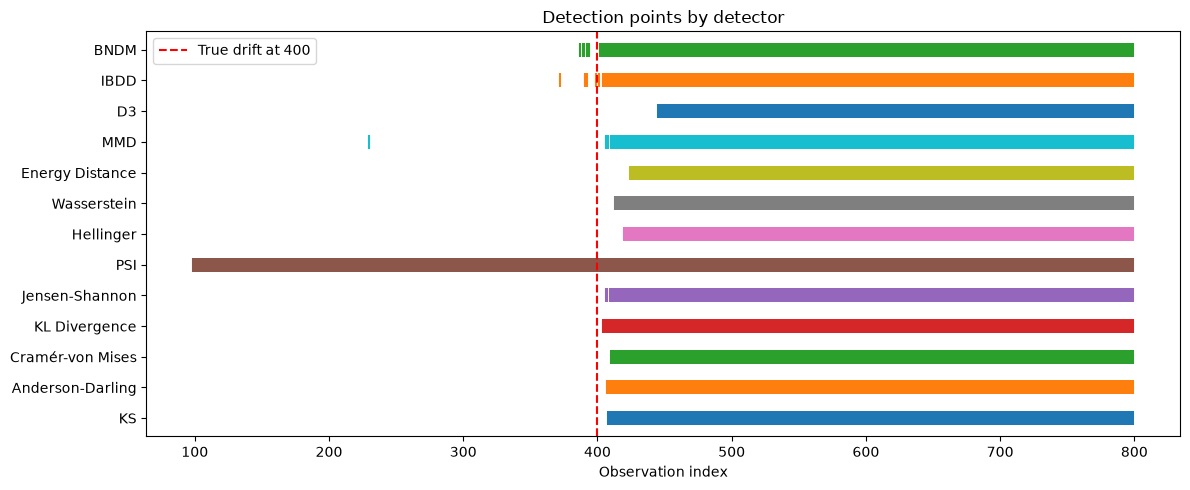

In [10]:
all_results = {**results, **results_dist, **results_multi}

fig, ax = plt.subplots(figsize=(12, 5))
names = list(all_results.keys())
for idx, (name, dets) in enumerate(all_results.items()):
    if dets:
        ax.scatter(dets, [idx] * len(dets), marker="|", s=100, linewidths=1.5)
    else:
        ax.scatter([], [])

ax.axvline(half, color="red", linestyle="--", label=f"True drift at {half}")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel("Observation index")
ax.set_title("Detection points by detector")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Categorical features with Chi-Square

The `ChiSquare` detector is designed for **categorical** (discrete) data.
It builds a contingency table per feature and applies the chi-square test
of independence.

In [11]:
from capymoa.drift.detectors.data_drift import ChiSquare

categories = ["a", "b", "c"]
cat_ref = rng.choice(categories, size=(N_REF, 2), p=[0.5, 0.3, 0.2])
cat_stream = np.vstack(
    [
        rng.choice(categories, size=(half, 2), p=[0.5, 0.3, 0.2]),
        rng.choice(categories, size=(half, 2), p=[0.1, 0.2, 0.7]),
    ]
)

chi2 = ChiSquare(window_size=WINDOW)
chi2.fit(cat_ref)

chi2_dets = []
for i, x in enumerate(cat_stream):
    chi2.add_element(x)
    if chi2.detected_change():
        chi2_dets.append(i)

print(
    f"Chi-Square: first detection at {chi2_dets[0] if chi2_dets else 'N/A'} "
    f"(total {len(chi2_dets)} detections)"
)

Chi-Square: first detection at 418 (total 382 detections)


## 7. Batch comparison with `compare()`

If you already have a test window, you can compare it against the
reference in one call. This skips the streaming loop and returns a
`DataDriftResult` directly.

In [12]:
from capymoa.drift.detectors.data_drift import KolmogorovSmirnov, MMD

X_no_drift = rng.normal(0, 1, size=(WINDOW, N_FEATURES))
X_drifted = rng.normal(SHIFT, 1, size=(WINDOW, N_FEATURES))

for label, DetCls, kwargs in [
    ("KS", KolmogorovSmirnov, {"window_size": WINDOW}),
    ("MMD", MMD, {"window_size": WINDOW, "n_permutations": 50, "sigma": 1.0}),
]:
    det = DetCls(**kwargs)
    det.fit(X_ref)

    r_same = det.compare(X_no_drift)
    r_drift = det.compare(X_drifted)

    print(f"\n{label}:")
    print(f"  Same distribution → drift={r_same.is_drift}, stat={r_same.statistic:.4f}")
    print(
        f"  Shifted           → drift={r_drift.is_drift}, stat={r_drift.statistic:.4f}"
    )


KS:
  Same distribution → drift=False, stat=0.1180
  Shifted           → drift=True, stat=0.9120

MMD:
  Same distribution → drift=False, stat=-0.0009
  Shifted           → drift=True, stat=0.6748


## 8. Auto-fit mode

If you do not have a separate reference dataset, you can let the detector
collect the first `N` observations as its reference by setting
`auto_fit_samples`. No explicit `fit()` call is needed.

In [13]:
from capymoa.drift.detectors.data_drift import KolmogorovSmirnov

ks_auto = KolmogorovSmirnov(window_size=WINDOW, auto_fit_samples=N_REF)

# Stream everything – the first N_REF samples are used as reference
all_data = np.vstack([X_ref, X_stream])
auto_dets = []
for i, x in enumerate(all_data):
    ks_auto.add_element(x)
    if ks_auto.detected_change():
        auto_dets.append(i)

# Drift is at N_REF + half
true_drift = N_REF + half
print(f"Auto-fit KS: first detection at {auto_dets[0] if auto_dets else 'N/A'}")
print(f"(True drift at observation {true_drift})")

Auto-fit KS: first detection at 908
(True drift at observation 900)


## 9. Feature names from pandas DataFrames

When you pass a `DataFrame` to `fit()`, the detector extracts column names
automatically. These appear in the `feature_names` attribute.

In [8]:
df_ref = pd.DataFrame(X_ref, columns=["temperature", "humidity"])

ks_df = KolmogorovSmirnov(window_size=WINDOW)
ks_df.fit(df_ref)

print(f"Feature names: {ks_df.feature_names}")

result = ks_df.compare(X_stream[half : half + WINDOW])
print(f"Per-feature drift: {result.feature_is_drift}")

Feature names: ['temperature', 'humidity']
Per-feature drift: {'temperature': np.True_, 'humidity': np.True_}


## Summary

| Category | Detectors | Data type |
|---|---|---|
| Statistical tests | KolmogorovSmirnov, AndersonDarling, CramerVonMises | Numeric (univariate per feature) |
| Distance-based | KLDivergence, JensenShannon, PSI, Hellinger, Wasserstein, EnergyDistance | Numeric (univariate per feature) |
| Multivariate | MMD, D3, IBDD | Numeric (full feature vector) |
| Bayesian | BNDM | Numeric (univariate per feature) |
| Categorical | ChiSquare | Categorical |

All detectors share the same API:

1. `fit(X_ref)` – set the reference distribution.
2. `add_element(x)` – stream a single observation.
3. `detected_change()` – check if drift was detected.
4. `compare(X_test)` – batch comparison returning a `DataDriftResult`.
5. `reset()` – clear the sliding window (keeps reference).

Use `auto_fit_samples` if no separate reference data is available.